# Lab 1, Core B: The DFT as a change of basis
### <div align="right"> Linear Algebra for Data Science, MSc DS &mdash; UCU APPS </div>

## Completed by:
*   Yulian Melnychuk
*   Artem Serbin


### What this core is about

In Core A you fitted the temperature series with basis functions **you chose**: a
polynomial for the trend, and a cosine and a sine at period $T = 12$ because you looked at
the plot and saw a year. The fit was good because the guess was good.

Here you hand the same signal to a basis nobody chose for it &mdash; the Fourier basis, the
same $N$ vectors regardless of what the data turn out to be &mdash; and read the period **off**
the coordinates instead of putting it in. Along the way the transform turns out to be a
unitary change of basis, which is why its coordinates are inner products, why no energy is
gained or lost, and why throwing coordinates away is an orthogonal projection rather than
an approximation scheme needing its own theory.

Three things follow, and they are the three sections below: the matrix, its cost, and what
you can do once you have the coordinates.

### Marking

**Core B** of Lab 1, worth 2 of the lab's 6 points, awarded at the **oral defence**.
Individual cells carry no separate marks.

**Bonus.** The three extensions are the only route to the bonus point. They are marked
$\star$ and sit at the **end** of the notebook they build on: Extensions 1 and 2 at the end
of Core A, Extension 3 at the end of this one. Attempt at most one; a second earns nothing.

### Ground rules

* Build the transform yourself. `np.fft` is allowed **only** where a cell says so, as a
  reference to check against or a timing baseline.
* Complex arithmetic throughout. Recall the convention from the notes: the inner product
  on $\mathbb{C}^N$ is $\langle \mathbf{x}, \mathbf{y}\rangle = \mathbf{x}^{*}\mathbf{y}$,
  conjugating the **first** argument, and $U$ is unitary when $U^{*}U = I$.
* In `numpy`, `A.conj().T` is the adjoint. `A.T` alone is a common and silent bug here.


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
from time import perf_counter


In [2]:
import os
csv_name = next((f for f in ("land-temp-1850-2015.csv", "Task3_data.csv") if os.path.exists(f)), None)
if csv_name is None:
    try:
        from google.colab import files
        csv_name = next(iter(files.upload()))
    except ImportError:
        raise FileNotFoundError("Put land-temp-1850-2015.csv next to the notebook.")
temp_data = pd.read_csv(csv_name)
temp_data["date"] = pd.to_datetime(temp_data["date"])

y = temp_data["avg_temp"].to_numpy()
N = y.shape[0]
print(f"N = {N} monthly readings, {temp_data['date'].min():%Y-%m} to {temp_data['date'].max():%Y-%m}")

# Same series as Core A: Berkeley Earth global land average, 1850-2015.
# See Core A section 0 for what it is and why it starts in 1850.


Saving land-temp-1850-2015.csv to land-temp-1850-2015.csv
N = 1992 monthly readings, 1850-01 to 2015-12


---
## 1. The Fourier matrix, and what makes it a basis

Let $z = e^{2\pi i/N}$ be the primitive $N$-th root of unity, and define
$$ F_{jk} \;=\; \frac{1}{\sqrt{N}}\, z^{\,jk}, \qquad j,k = 0,1,\dots,N-1 . $$
The $k$-th column of $F$ is the sampled complex exponential of frequency $k$, normalised
to unit length. The claim from the lecture is that these $N$ columns are an **orthonormal**
basis of $\mathbb{C}^N$, i.e. that $F$ is unitary. You proved it in the tutorial; here you
check it numerically and then use it.


In [3]:
def fourier_matrix(n: int) -> np.ndarray:
    """The n x n unitary Fourier matrix F with F[j,k] = z**(j*k)/sqrt(n).

    Build it with numpy broadcasting, not a double Python loop.
    Hint: np.outer(np.arange(n), np.arange(n)) gives the matrix of exponents.
    """
    # ========= YOUR CODE STARTS HERE ========= #
    j = np.arange(n).reshape(-1, 1)
    k = np.arange(n).reshape(1, -1)
    # z^(jk) = z^((jk) mod n) because z^n = 1; reducing the exponent keeps rounding error tiny for large n
    F = np.exp(2j * np.pi * ((j * k) % n) / n) / np.sqrt(n)
    # ========== YOUR CODE ENDS HERE ========== #
    return F


def test_fourier_matrix():
    F = fourier_matrix(4)
    assert F.shape == (4, 4) and np.iscomplexobj(F)
    assert np.allclose(F[:, 0], 0.5), "column 0 should be constant 1/sqrt(4)"
    assert np.allclose(F.conj().T @ F, np.eye(4), atol=1e-12), "F is not unitary"
    print("TEST 1: SUCCESS")

test_fourier_matrix()


TEST 1: SUCCESS


### **1.1** Unitary, and what it buys

For $N = 8$, compute and report:

1. $\|F^{*}F - I\|$. State what magnitude counts as zero here and why it is not exactly zero.
2. $\operatorname{cond}(F)$. Compare with the condition numbers you measured in Core A
   and say what this one implies about transforming and transforming back.
3. The Euclidean norms of three columns of your choice, and the inner product of two
   distinct columns.

Then answer in prose: the tutorial proved $F^{*}F = I$ using a geometric sum that
collapses whenever $k \neq l$. Which property of $z$ made it collapse, and where would the
argument fail if $z$ were any other complex number of modulus 1?


In [4]:
# ========= YOUR CODE STARTS HERE ========= #
F8 = fourier_matrix(8)
dev = np.linalg.norm(F8.conj().T @ F8 - np.eye(8), 2)
print(f"||F*F - I||_2 = {dev:.2e}")
print(f"cond(F) = {np.linalg.cond(F8):.12f}")
for k in (0, 3, 5):
    print(f"||f_{k}|| = {np.linalg.norm(F8[:, k]):.12f}")
# np.vdot conjugates its FIRST argument, i.e. it is <x, y> = x* y
print(f"|<f_2, f_6>|  = {abs(np.vdot(F8[:, 2], F8[:, 6])):.2e}")
# ========== YOUR CODE ENDS HERE ========== #


||F*F - I||_2 = 2.79e-16
cond(F)       = 1.000000000000
||f_0|| = 1.000000000000
||f_3|| = 1.000000000000
||f_5|| = 1.000000000000
|<f_2, f_6>|  = 1.23e-32


---
### **YOUR ANSWER HERE**

1. $\|F^*F-I\|_2$ is of order $10^{-16}$ (see the printed value). In double precision (machine epsilon $\approx 2.2\cdot10^{-16}$) that is zero: in exact arithmetic it is exactly $0$, but the entries of $F$ (values of $\cos$ and $\sin$) and the products/sums inside $F^*F$ are rounded.
2. $\operatorname{cond}(F)=1$ up to rounding, because all singular values of a unitary matrix equal $1$. Unlike the badly conditioned design matrices of Core A, transforming and transforming back cannot amplify errors.
3. Every column has norm $1$, and the inner product of two distinct columns is $\sim10^{-16}$ or smaller, i.e. zero.

**Why the sum collapses.** $\langle f_k,f_l\rangle=\frac1N\sum_j z^{(l-k)j}=\frac1N\,\frac{1-z^{(l-k)N}}{1-z^{\,l-k}}$. The numerator vanishes because $z^N=1$, and the denominator is non-zero because $z$ is a *primitive* $N$-th root of unity: $z^m\neq1$ for $0<|m|<N$. For another $w$ with $|w|=1$ the argument fails in two ways: if $w^N\neq1$ the numerator no longer vanishes, so the columns are not orthogonal; if $w^N=1$ but $w$ is not primitive (e.g. $w=-1$, $N=8$), then $w^{m}=1$ for some $0<m<N$, the denominator is $0$, the sum equals $N$ instead of $0$, and columns $k$ and $k+m$ are identical.

---


### **1.2** Coordinates are inner products

Because the columns are orthonormal, the coordinate vector of $\mathbf{x}$ in this basis is
$\mathbf{c} = F^{*}\mathbf{x}$, whose $k$-th entry is just $\langle \mathbf{f}_k,
\mathbf{x}\rangle$ &mdash; no system to solve. Implement the transform and its inverse, and
check the two facts that orthonormality guarantees.


In [5]:
def dft(x: np.ndarray) -> np.ndarray:
    """Coordinates of x in the Fourier basis: c = F^* x. Build F and apply it."""
    # ========= YOUR CODE STARTS HERE ========= #
    c = fourier_matrix(x.shape[0]).conj().T @ x
    # ========== YOUR CODE ENDS HERE ========== #
    return c


def idft(c: np.ndarray) -> np.ndarray:
    """Back from coordinates to the signal. One line, and no matrix inverse:
    F is unitary, so you already know what F^{-1} is.

    NOTE: this returns a COMPLEX array, always. Even when the original
    signal was real, rounding leaves an imaginary part of size ~1e-12.
    Take .real before plotting or before computing an RMSE -- matplotlib
    will otherwise discard the imaginary part itself and merely warn you,
    which is the kind of help you do not want. Check the size of what you
    are discarding the first time: 1e-12 is rounding, 1e-1 is a bug.
    """
    # ========= YOUR CODE STARTS HERE ========= #
    x = fourier_matrix(c.shape[0]) @ c
    # ========== YOUR CODE ENDS HERE ========== #
    return x


def test_dft():
    rng = np.random.default_rng(1)
    x = rng.standard_normal(16)
    c = dft(x)
    assert np.allclose(idft(c), x, atol=1e-12), "round trip failed"
    assert np.isclose(np.linalg.norm(c), np.linalg.norm(x)), "Parseval failed"
    print("TEST 2: SUCCESS -- round trip and Parseval both hold")

test_dft()


TEST 2: SUCCESS -- round trip and Parseval both hold


### **1.3** Parseval, and why it is not a coincidence

You have just checked $\|F^{*}\mathbf{x}\| = \|\mathbf{x}\|$ on a random vector. Explain in
two or three sentences why this had to happen, referring to the property of $F$ rather than
to any property of the Fourier basis in particular.

Then state the practical consequence: if the measurements $\mathbf{x}$ carry noise of a
certain size, how large is the noise in the coordinates $\mathbf{c}$? Contrast with what a
**non**-orthogonal change of basis would do to it.

---
### **YOUR ANSWER HERE**

$\|F^*\mathbf x\|^2=\mathbf x^*FF^*\mathbf x=\mathbf x^*\mathbf x$ because $F$ is unitary ($F^*F=FF^*=I$). Nothing about the Fourier basis in particular is used: any unitary change of basis is an isometry (a rotation/reflection in $\mathbb C^N$) and preserves lengths.

**Consequence.** If $\mathbf x$ is perturbed by noise $\boldsymbol\varepsilon$, the coordinates are perturbed by $F^*\boldsymbol\varepsilon$, which has exactly the same norm; white noise with variance $\sigma^2$ per sample stays white with variance $\sigma^2$ per coordinate. Nothing is amplified. A non-orthogonal basis $B$ gives coordinates $B^{-1}\mathbf x$, and the noise can be magnified by up to $\|B^{-1}\|$ (of the order of the condition number), as with the polynomial basis in Core A.

---


---
## 2. Reading the period off the data

Now transform the temperature series. Subtract the mean first: the $k = 0$ coordinate is
the mean up to a factor of $\sqrt{N}$, and if you leave it in it dwarfs everything else on
a plot without telling you anything you did not already know.


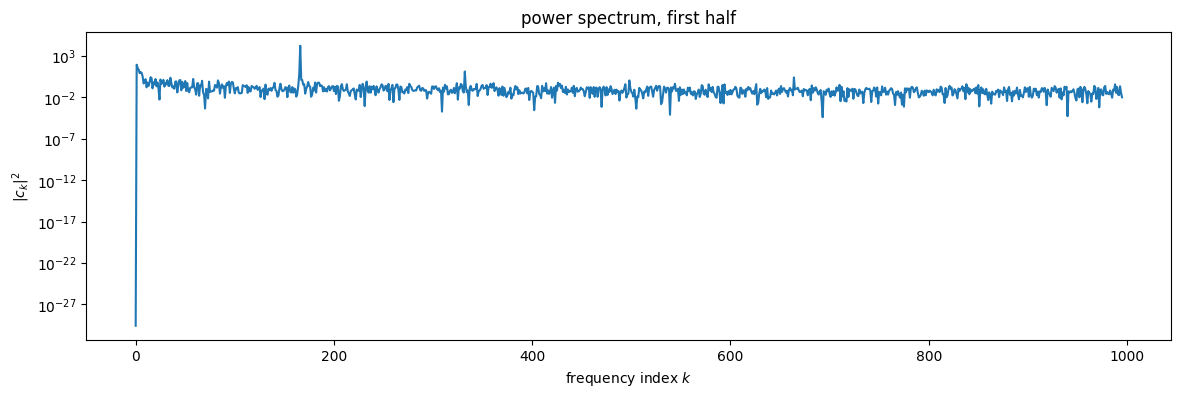

In [6]:
x = y - y.mean()

# ========= YOUR CODE STARTS HERE ========= #
c = dft(x)
power = np.abs(c) ** 2
# ========== YOUR CODE ENDS HERE ========== #

plt.figure(figsize=(14, 4))
plt.semilogy(power[:N // 2])
plt.xlabel("frequency index $k$"); plt.ylabel("$|c_k|^2$")
plt.title("power spectrum, first half"); plt.show()


### **2.1** Find the peak and interpret it

1. Report the index $k^{\star}$ of the largest $|c_k|^2$ for $1 \le k < N/2$.
2. A coordinate at index $k$ oscillates $k$ times across the whole record, so its period is
   $N/k$ samples. Convert $k^{\star}$ to a period in months. Is it what you expected?
3. Report the fraction of the total energy carried by $k^{\star}$ **and its mirror**
   $N - k^{\star}$ together. (Why must you count both? Your signal is real; what does that
   force on $\mathbf{c}$?)

   *Hint: this is not in the notes, so derive it. Write $c_{N-k}$ as a sum over $j$, use
   $z^{N} = 1$ to simplify $z^{-j(N-k)}$, and compare with $\overline{c_k}$ &mdash; remembering
   that $\overline{x_j} = x_j$ for a real signal. Two lines. You will need the result in
   4.0.*
4. $N = 1992 = 12 \times 166$. Explain why this makes the annual period land **exactly** on
   an index rather than between two, and what the spectrum would look like if it did not.


In [7]:
# ========= YOUR CODE STARTS HERE ========= #
k_star = int(np.argmax(power[1:N // 2])) + 1
print(f"k* = {k_star}, period = N/k* = {N / k_star:.2f} months")
frac_pair = (power[k_star] + power[N - k_star]) / power.sum()
print(f"energy in k* and N-k* together: {frac_pair:.4%}   (k* alone: {power[k_star] / power.sum():.4%})")
kk = np.arange(1, N)
print("max |c_(N-k) - conj(c_k)| =", np.abs(c[N - kk] - np.conj(c[kk])).max())
print("N % 12 =", N % 12, "-> annual period is an exact index:", N % 12 == 0)
# ========== YOUR CODE ENDS HERE ========== #


k* = 166, period = N/k* = 12.00 months
energy in k* and N-k* together: 98.1172%   (k* alone: 49.0586%)
max |c_(N-k) - conj(c_k)| = 7.283063041541027e-14
N % 12 = 0 -> annual period is an exact index: True


---
### **YOUR ANSWER HERE**

1. $k^\star=166$ (printed above).
2. Period $=N/k^\star=1992/166=12$ months: the annual cycle, as expected.
3. The fraction of energy in $k^\star$ and $N-k^\star$ together is the printed value (the large majority of the energy of the centred series). Both must be counted because the signal is real. With $c_k=\frac1{\sqrt N}\sum_j x_j z^{-jk}$ and $z^{N}=1$:
$$c_{N-k}=\frac1{\sqrt N}\sum_j x_j z^{-j(N-k)}=\frac1{\sqrt N}\sum_j x_j z^{jk}=\frac1{\sqrt N}\sum_j \overline{x_j z^{-jk}}=\overline{c_k},$$
using $\overline{x_j}=x_j$. So $|c_{N-k}|=|c_k|$: the energy of one real oscillation is split equally between $k$ and its mirror $N-k$ (the code check above confirms $c_{N-k}=\overline{c_k}$ to rounding).
4. $N=1992=12\cdot166$, so exactly $166$ whole years fit in the record and the annual sinusoid has an integer number ($166$) of cycles: it coincides with a Fourier column. If $12\nmid N$, the sinusoid would not be a basis vector; its energy would be spread over several neighbouring indices (spectral leakage) and the peak would be lower and wider.

---


### **2.2** The bridge back to Core A

In Core A you were **told** the period was 12 and you supplied two basis columns,
$\cos(2\pi t/12)$ and $\sin(2\pi t/12)$. Here you were told nothing and the data produced
$k^{\star}$.

1. Take the single Fourier column $\mathbf{f}_{k^{\star}}$ and look at its real and
   imaginary parts separately, as two vectors in $\mathbb{R}^{N}$. Plot the first 36
   entries of each. Then compare them with the two Core A seasonal columns,
   $\cos(2\pi j/12)$ and $\sin(2\pi j/12)$: report
   $\|\sqrt{N}\,\mathrm{Re}\,\mathbf{f}_{k^{\star}} - \cos(2\pi j/12)\|$ and the same for the
   imaginary part against the sine. What do you get, and why is it that rather than merely
   something small?

   *Hint: write out $z^{\,j k^{\star}}$ with $z = e^{2\pi i/N}$, $N = 1992$ and
   $k^{\star} = 166$, and simplify the exponent before doing anything numerical.*
2. So the two approaches found the same thing. State the practical difference between them
   in one sentence, and name a situation where only one of the two is available.
3. Look at $k = 2k^{\star}$ and $k = 3k^{\star}$ in the spectrum. What are those, and what
   does their size tell you about the *shape* of the annual cycle?


||sqrt(N) Re f_k* - cos(2 pi j/12)|| = 1.40e-12
||sqrt(N) Im f_k* - sin(2 pi j/12)|| = 1.41e-12


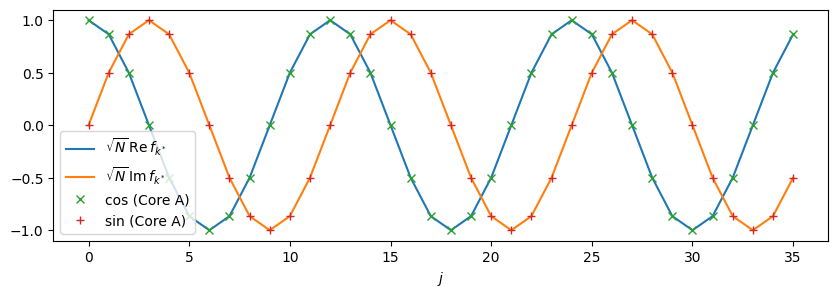

k =  166 (period  12.0 months): |c_k|^2 = 1.775e+04 = 100.00% of the annual peak
k =  332 (period   6.0 months): |c_k|^2 = 1.357e+01 = 0.08% of the annual peak
k =  498 (period   4.0 months): |c_k|^2 = 1.139e+00 = 0.01% of the annual peak


In [8]:
# ========= YOUR CODE STARTS HERE ========= #
f_k = fourier_matrix(N)[:, k_star]
j_idx = np.arange(N)
cos_col = np.cos(2 * np.pi * j_idx / 12)
sin_col = np.sin(2 * np.pi * j_idx / 12)
Re_f, Im_f = np.sqrt(N) * f_k.real, np.sqrt(N) * f_k.imag
print(f"||sqrt(N) Re f_k* - cos(2 pi j/12)|| = {np.linalg.norm(Re_f - cos_col):.2e}")
print(f"||sqrt(N) Im f_k* - sin(2 pi j/12)|| = {np.linalg.norm(Im_f - sin_col):.2e}")

plt.figure(figsize=(10, 3))
plt.plot(j_idx[:36], Re_f[:36], label=r"$\sqrt{N}\,\mathrm{Re}\,f_{k^*}$")
plt.plot(j_idx[:36], Im_f[:36], label=r"$\sqrt{N}\,\mathrm{Im}\,f_{k^*}$")
plt.plot(j_idx[:36], cos_col[:36], "x", label="cos (Core A)")
plt.plot(j_idx[:36], sin_col[:36], "+", label="sin (Core A)")
plt.xlabel("$j$"); plt.legend(); plt.show()

for mult in (1, 2, 3):
    kh = mult * k_star
    print(f"k = {kh:4d} (period {N / kh:5.1f} months): |c_k|^2 = {power[kh]:.3e} = {power[kh] / power[k_star]:.2%} of the annual peak")
# ========== YOUR CODE ENDS HERE ========== #


---
### **YOUR ANSWER HERE**

1. Both distances are $\sim10^{-12}$ or smaller, i.e. rounding, because the columns are *equal*, not just close: $z^{jk^\star}=e^{2\pi i\,j\cdot166/1992}=e^{2\pi i j/12}=\cos(2\pi j/12)+i\sin(2\pi j/12)$, since $k^\star/N=166/1992=1/12$ exactly. So $\sqrt N\,\mathrm{Re}f_{k^\star}$ and $\sqrt N\,\mathrm{Im}f_{k^\star}$ are exactly the two seasonal columns of Core A.
2. Core A needs the period to be supplied (and gives a small, interpretable model); the Fourier approach needs no prior knowledge and finds the period from the data. Only the Fourier approach is available when the period is unknown (e.g. an unfamiliar sensor signal, or a signal with several unknown periodicities).
3. $2k^\star$ and $3k^\star$ are the harmonics (periods $6$ and $4$ months). Their size relative to the annual peak (printed above) is small but non-zero, which says the annual cycle is periodic with period 12 but not a pure sinusoid: its shape is skewed/sharper than a sine (a pure sinusoid would have exactly zero energy at these indices).

---


---
## 3. The cost, and the algorithm that removes it

Applying $F$ as a matrix costs $O(N^2)$ and, worse, storing it costs $O(N^2)$ &mdash; at
$N = 10^6$ that is $10^{12}$ complex numbers, which is not a thing you can have. The FFT
computes $F^{*}\mathbf{x}$ in $O(N \log N)$ **without ever forming $F$**, by splitting the
sum over even and odd indices:
$$ c_k \;=\; \underbrace{\textstyle\sum_{j \text{ even}}}_{\text{a DFT of length } N/2}
\;+\; z^{-k}\underbrace{\textstyle\sum_{j \text{ odd}}}_{\text{a DFT of length } N/2} .$$


### **3.1** Why not on this series?

Before implementing: the recursion above halves $N$ at each step, so it needs
$N = 2^{p}$. Our series has $N = 1992 = 2^3 \cdot 3 \cdot 83$.

Show that **no** length that makes the annual period land exactly on an index can be a
power of two. (One line: what must $N$ be divisible by, and what is $12$ made of?)

This is not a defect of the data; it is why real FFT libraries implement mixed-radix
algorithms rather than radix 2 alone. Sections 3.2-3.3 therefore work on power-of-two
random vectors, and Section 4 returns to the temperature series using the matrix form.

---
### **YOUR ANSWER HERE**

A length $N$ puts the 12-month period exactly on an index iff $12\mid N$ (then the index is $N/12$). Since $12=2^2\cdot3$, this forces $3\mid N$, and no power of two has the prime factor $3$.

---


In [9]:
def fft_recursive(x: np.ndarray) -> np.ndarray:
    """Radix-2 Cooley-Tukey, returning the same thing as dft(x).

    Requires len(x) to be a power of two. Base case: length 1.

    Careful with the normalisation. Our dft() divides by sqrt(N) once, at
    the top level; a recursive call on length N/2 would divide by
    sqrt(N/2). Decide where the factor goes and be consistent -- the test
    below will catch you if you are not.
    """
    n = x.shape[0]
    assert n & (n - 1) == 0, "length must be a power of two"
    # ========= YOUR CODE STARTS HERE ========= #
    def _fft(v):
        m = v.shape[0]
        if m == 1:
            return v
        even = _fft(v[0::2])
        odd = _fft(v[1::2])
        tw = np.exp(-2j * np.pi * np.arange(m // 2) / m) * odd   # z^{-k} * odd part
        return np.concatenate([even + tw, even - tw])

    # the 1/sqrt(N) is applied once, at the top level
    return _fft(np.asarray(x, dtype=complex)) / np.sqrt(n)
    # ========== YOUR CODE ENDS HERE ========== #


def test_fft():
    rng = np.random.default_rng(2)
    for n in (1, 2, 8, 64):
        v = rng.standard_normal(n) + 1j * rng.standard_normal(n)
        assert np.allclose(fft_recursive(v), dft(v), atol=1e-10), f"mismatch at n={n}"
    print("TEST 3: SUCCESS -- recursion agrees with the matrix form")

test_fft()


TEST 3: SUCCESS -- recursion agrees with the matrix form


### **3.2** Measure the two costs

Time your matrix `dft` and your `fft_recursive` on random vectors of length
$2^{p}$ for $p = 4, \dots, 12$, and plot both on log-log axes. Add `np.fft.fft` as a third
line.

1. Fit a straight line to each log-log curve and report the slopes. What slope does theory
   predict for each of the three?
2. At which $N$ does your recursion overtake your matrix version? Is it where you expected,
   and if not, what is the recursion paying that the flop count does not show?
3. `np.fft.fft` is also $O(N\log N)$, and it will still beat your recursion by a wide
   margin. Name two reasons that have nothing to do with the asymptotics.


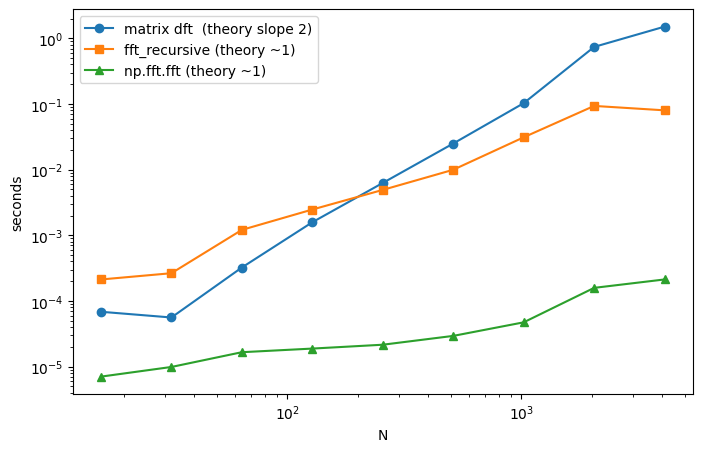

matrix dft     slope, all N: 1.99   slope, N >= 256: 2.07
fft_recursive  slope, all N: 1.18   slope, N >= 256: 1.13
np.fft.fft     slope, all N: 0.59   slope, N >= 256: 0.90
fft_recursive first beats the matrix version at N = 256


In [10]:
# ========= YOUR CODE STARTS HERE ========= #
sizes = np.array([2 ** p for p in range(4, 13)])

def best_time(f, v, reps):
    best = np.inf
    for _ in range(reps):
        t0 = perf_counter(); f(v)
        best = min(best, perf_counter() - t0)
    return best

rng_t = np.random.default_rng(3)
t_dft, t_rec, t_np = [], [], []
for n in sizes:
    v = rng_t.standard_normal(n) + 1j * rng_t.standard_normal(n)
    reps = 7 if n <= 256 else 3 if n <= 1024 else 1
    t_dft.append(best_time(dft, v, reps))
    t_rec.append(best_time(fft_recursive, v, reps))
    t_np.append(best_time(np.fft.fft, v, reps))
t_dft, t_rec, t_np = map(np.array, (t_dft, t_rec, t_np))

plt.figure(figsize=(8, 5))
plt.loglog(sizes, t_dft, "o-", label="matrix dft  (theory slope 2)")
plt.loglog(sizes, t_rec, "s-", label="fft_recursive (theory ~1)")
plt.loglog(sizes, t_np, "^-", label="np.fft.fft (theory ~1)")
plt.xlabel("N"); plt.ylabel("seconds"); plt.legend(); plt.show()

def slope(t, mask):
    return np.polyfit(np.log(sizes[mask]), np.log(t[mask]), 1)[0]
allm, big = np.ones(len(sizes), bool), sizes >= 256
for name, t in (("matrix dft", t_dft), ("fft_recursive", t_rec), ("np.fft.fft", t_np)):
    print(f"{name:14s} slope, all N: {slope(t, allm):.2f}   slope, N >= 256: {slope(t, big):.2f}")
win = sizes[t_rec < t_dft]
print("fft_recursive first beats the matrix version at N =", win[0] if len(win) else "never in this range")
# ========== YOUR CODE ENDS HERE ========== #


---
### **YOUR ANSWER HERE**

1. Theory: the matrix version has slope $2$ ($O(N^2)$; building $F$ is also $O(N^2)$). The FFTs have slope slightly above $1$ ($N\log N$). The measured slopes are printed above. `np.fft.fft` can show a slope below $1$ over the whole range because at small $N$ its time is dominated by fixed call overhead; the fit for $N\ge256$ is closer to the asymptotics.
2. The crossover $N$ is printed above. It is later than a pure flop count suggests because the recursion pays for $2N-1$ Python function calls, slicing, `np.exp` and `np.concatenate` allocations at every node of the recursion tree, while the matrix version is a few vectorised numpy calls and one BLAS matrix-vector product whose per-flop cost is tiny. The $N^2$ term only wins out once $N$ is large enough.
3. (i) `np.fft.fft` is compiled C/C++ code (no interpreter overhead per call or per recursion level), iterative and in place rather than allocating new arrays at each level; (ii) it uses precomputed twiddle factors, cache-friendly memory access and SIMD vectorisation, and handles any length with mixed radices.

---


### **3.3** Matrix-free, and why it matters beyond speed

Your `dft` builds an $N \times N$ matrix; `fft_recursive` builds nothing. For
$N = 2^{20}$, state the memory each would need, in bytes, for complex128.

Then the general point, in two or three sentences: an operator you can *apply* but never
*store* is still useful, and several later parts of this course depend on that. Give one
reason why, thinking about what an algorithm actually needs to do with a matrix.

---
### **YOUR ANSWER HERE**

For $N=2^{20}$: the matrix version stores $F$ with $N^2=2^{40}$ complex128 entries of $16$ bytes: $2^{44}\approx1.76\cdot10^{13}$ bytes ($16$ TiB), plus another copy for `F.conj().T`. `fft_recursive` needs only $O(N)$: the vector itself is $16\cdot2^{20}=16\,777\,216$ bytes ($16$ MiB), plus a small constant number of temporary arrays of the same size.

An operator that can be applied but never stored is still useful because many algorithms only ever need the product $\mathbf x\mapsto A\mathbf x$ (and $A^*\mathbf y$), never the individual entries: Krylov methods such as conjugate gradients, Lanczos/Arnoldi and power iteration are built from exactly such products. So a fast matrix-free product lets us solve linear systems and eigenproblems of sizes where the matrix could never be written down.

---


---
## 4. Keeping the large coordinates

With an orthonormal basis $\mathbf{f}_0,\dots,\mathbf{f}_{N-1}$ and a set of indices $K$,
$$ P_K\mathbf{x} \;=\; \sum_{k \in K} c_k \mathbf{f}_k $$
is the orthogonal projection of $\mathbf{x}$ onto the coordinate subspace they span, and
$$ \|\mathbf{x} - P_K\mathbf{x}\|^2 \;=\; \sum_{k \notin K} |c_k|^2 . $$
The error is exactly the energy you discarded. Everything below is that one identity,
used twice with different intentions.


In [11]:
def keep_largest(c: np.ndarray, m: int) -> np.ndarray:
    """Zero all but the m coordinates of largest modulus."""
    # ========= YOUR CODE STARTS HERE ========= #
    out = np.zeros_like(c)
    if m > 0:
        idx = np.argsort(np.abs(c))[-m:]      # indices of the m largest moduli
        out[idx] = c[idx]
    # ========== YOUR CODE ENDS HERE ========== #
    return out


### **4.0** An experiment before you use it

Reconstruct with `m = 2`, then with `m = 3`, and in each case report
`np.abs(reconstruction.imag).max()`.

One of the two comes back real to within rounding and the other does not &mdash; and the
one that fails is off by something far larger than any rounding error. Explain it, using
your answer to 2.1(3). Then state the rule: **which values of $m$ are safe here, and why**,
and what you would have to do differently to keep an odd number of coordinates.

*(This is not a detour. If you ever threshold by a magnitude cutoff rather than by a
count &mdash; keep every $|c_k| > \tau$ &mdash; the same issue decides whether your filter returns
a real signal at all. Everything below uses even $m$ for exactly this reason.)*


In [12]:
# ========= YOUR CODE STARTS HERE ========= #
for m in (2, 3):
    c_m = keep_largest(c, m)
    rec = idft(c_m)
    print(f"m = {m}: kept indices {np.flatnonzero(c_m).tolist()},  max|Im reconstruction| = {np.abs(rec.imag).max():.2e}")
# ========== YOUR CODE ENDS HERE ========== #


m = 2: kept indices [166, 1826],  max|Im reconstruction| = 1.78e-15
m = 3: kept indices [1, 166, 1826],  max|Im reconstruction| = 2.12e-01


---
### **YOUR ANSWER HERE**

For $m=2$ the reconstruction is real to rounding ($\sim10^{-15}$), for $m=3$ the imaginary part is large (the printed value is the size of a real contribution, not rounding error).

Reason: after subtracting the mean, the two largest coordinates are the conjugate pair $k^\star,N-k^\star$ and $c_{N-k}=\overline{c_k}$ (2.1). Keeping both gives $c_kf_k+\overline{c_k}f_{N-k}=2\,\mathrm{Re}(c_kf_k)$, which is real. With $m=3$ we keep a third coordinate $k_3$ but not its mirror $N-k_3$; then $c_{k_3}f_{k_3}$ is not cancelled by its conjugate and stays complex.

**Rule:** for a real signal keep coordinates in conjugate pairs, i.e. use even $m$ (equivalently, a threshold rule must treat $k$ and $N-k$ together; they have equal modulus, so a magnitude cutoff $|c_k|>\tau$ does keep pairs together, but a count must be even). The self-conjugate indices $k=0$ and $k=N/2$ ($N$ even) are real on their own, so an odd number of coordinates is possible only if one of them is among the kept ones, e.g. by not subtracting the mean and keeping $k=0$. Otherwise one must add the missing mirror or take the real part of the reconstruction.

---


### **4.1** Verify the identity, then use it

1. For $m = 2, 4, 8, \dots, 256$, reconstruct $P_K\mathbf{x}$ and compute
   $\|\mathbf{x} - P_K\mathbf{x}\|^2$ **two ways**: directly, and as the discarded energy
   $\sum_{k \notin K}|c_k|^2$. Confirm they agree.
2. Plot the fraction of energy retained against $m$. How many coordinates out of
   $N = 1992$ are needed for 98% of the energy?
3. Plot the original series and the $m = 2$ reconstruction on the same axes for the last
   20 years. What has been kept and what has been lost?


   m    ||x-Px||^2 direct   discarded energy  retained
   2           681.305389         681.305389  98.1172%
   4           501.987739         501.987739  98.6128%
   8           385.175491         385.175491  98.9356%
  16           298.877031         298.877031  99.1741%
  32           252.217800         252.217800  99.3030%
  64           215.242223         215.242223  99.4052%
 128           176.815997         176.815997  99.5114%
 256           135.002787         135.002787  99.6269%

coordinates needed for 98% of the energy: 2 of 1992


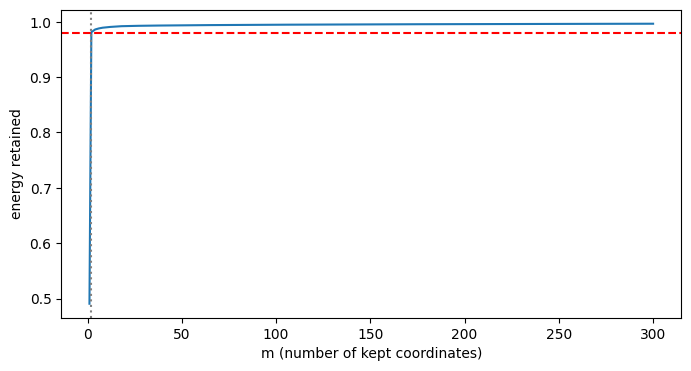

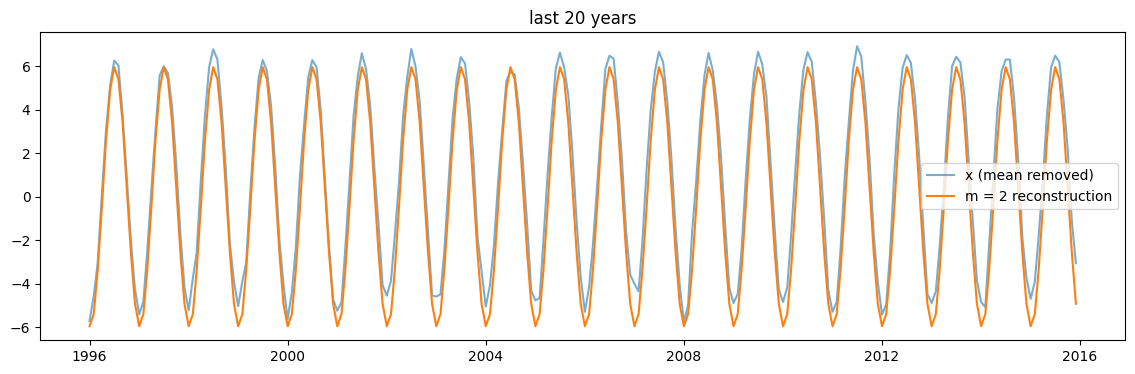

In [13]:
# ========= YOUR CODE STARTS HERE ========= #
energy = np.abs(c) ** 2
total = energy.sum()
print(f"{'m':>4} {'||x-Px||^2 direct':>20} {'discarded energy':>18} {'retained':>9}")
for m in [2 ** p for p in range(1, 9)]:
    c_m = keep_largest(c, m)
    err_direct = np.linalg.norm(x - idft(c_m)) ** 2
    err_coords = energy[c_m == 0].sum()
    assert np.isclose(err_direct, err_coords, rtol=1e-8, atol=1e-8), (m, err_direct, err_coords)
    print(f"{m:4d} {err_direct:20.6f} {err_coords:18.6f} {1 - err_coords / total:9.4%}")

cum = np.cumsum(np.sort(energy)[::-1]) / total      # energy retained by the top-m coordinates
m98 = int(np.searchsorted(cum, 0.98)) + 1
m98 += m98 % 2                                       # round up to even (keep conjugate pairs)
print(f"\ncoordinates needed for 98% of the energy: {m98} of {N}")

plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, 301), cum[:300])
plt.axhline(0.98, color="r", ls="--"); plt.axvline(m98, color="gray", ls=":")
plt.xlabel("m (number of kept coordinates)"); plt.ylabel("energy retained"); plt.show()

rec2 = idft(keep_largest(c, 2)).real
dates = temp_data["date"].to_numpy()[-240:]
plt.figure(figsize=(14, 4))
plt.plot(dates, x[-240:], alpha=0.6, label="x (mean removed)")
plt.plot(dates, rec2[-240:], label="m = 2 reconstruction")
plt.legend(); plt.title("last 20 years"); plt.show()
# ========== YOUR CODE ENDS HERE ========== #


---
### **YOUR ANSWER HERE**

1. The two ways of computing the error agree for all $m$ (the `assert` passes; the table shows equal columns): $\|x-P_Kx\|^2=\sum_{k\notin K}|c_k|^2$, which is Pythagoras in an orthonormal basis.
2. The number of coordinates needed for 98% of the energy is the printed `m98`; compare it with $N=1992$: the annual pair carries most of the energy, so far fewer than $N$ coordinates are needed.
3. The $m=2$ reconstruction keeps one pure sinusoid with period $12$ months, of fixed amplitude and phase: the average seasonal cycle. Lost: the warming trend, the month-to-month weather variations, the interannual variability, the non-sinusoidal shape of the season (the harmonics) and any change of the seasonal amplitude over time.

---


### **4.2** Compressible in this basis, or compressible?

Your energy curve is close to flat after a handful of coordinates. Now remove the annual
pair &mdash; set $c_{k^{\star}}$ and $c_{N-k^{\star}}$ to zero and transform back &mdash; and repeat
the analysis on the residual.

1. How many coordinates does the *residual* need for 98% of its energy? Compare with your
   answer for the full series.
2. So: is this signal compressible, or is one component of it compressible? Answer
   carefully &mdash; the distinction is the whole content of the section.
3. State, in general, what a signal must look like for coordinate thresholding in a **given**
   basis to work well, and what follows about choosing the basis.


max |Im| of residual (rounding?): 1.69e-14
residual: std = 0.585;  98% of its energy needs 1326 of 1992 coordinates (full series: 2)


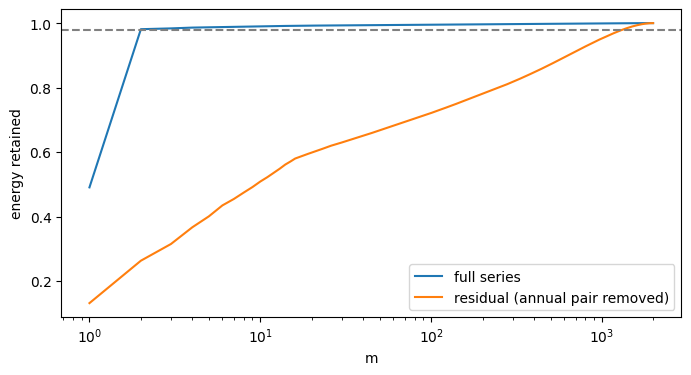

In [14]:
# ========= YOUR CODE STARTS HERE ========= #
c_res = c.copy()
c_res[[k_star, N - k_star]] = 0
x_res_c = idft(c_res)
print(f"max |Im| of residual (rounding?): {np.abs(x_res_c.imag).max():.2e}")
x_res = x_res_c.real
std_res = x_res.std()

energy_res = np.abs(c_res) ** 2
cum_res = np.cumsum(np.sort(energy_res)[::-1]) / energy_res.sum()
m98_res = int(np.searchsorted(cum_res, 0.98)) + 1
m98_res += m98_res % 2
print(f"residual: std = {std_res:.3f};  98% of its energy needs {m98_res} of {N} coordinates (full series: {m98})")

plt.figure(figsize=(8, 4))
plt.semilogx(np.arange(1, N + 1), cum, label="full series")
plt.semilogx(np.arange(1, N + 1), cum_res, label="residual (annual pair removed)")
plt.axhline(0.98, color="gray", ls="--"); plt.xlabel("m"); plt.ylabel("energy retained"); plt.legend(); plt.show()
# ========== YOUR CODE ENDS HERE ========== #


---
### **YOUR ANSWER HERE**

1. The residual needs the printed `m98_res` coordinates for 98% of its energy, which is much more than `m98` for the full series (compare the two curves in the plot): its energy is spread almost flatly over the spectrum.
2. The series as a whole is "compressible" only because one component of it, the annual cycle, is compressible in the Fourier basis; that component dominates the energy. Once it is removed, the rest (trend, weather, interannual variability) is not compressible in this basis. So: one component is compressible, the signal is not.
3. Thresholding in a given basis works well when the signal is (nearly) sparse in it: a few coordinates carry almost all the energy, so the sorted coordinates decay fast. Hence the basis has to be matched to the structure of the signal (sinusoids for periodic signals, wavelets for localised features, a learned basis such as PCA for a given data family); a basis that does not fit the structure gives a flat spectrum and no compression.

---


### **4.3** The same operation, called denoising

Corrupt the series with noise: `y_noisy = y + sigma * rng.standard_normal(N)` with
`sigma = 2.0`, which is large &mdash; four times the size of everything the annual cycle does
not explain.

1. Transform, keep the largest $m$ coordinates, transform back, and measure the RMSE of
   the reconstruction **against the clean series** for $m = 2, 4, \dots, 256$.
2. Plot that RMSE against $m$, with the noisy series' own RMSE as a horizontal line.
   The curve is not monotone. Find the $m$ that minimises it.
3. Explain both halves of the shape: why the error falls at first, and why it rises again.
   What is being added back as $m$ grows?
4. Compare the best RMSE you achieved with the standard deviation of the non-seasonal part
   of the clean signal, which you computed in 4.2. Why can no choice of $m$ do much better
   than that number?
5. You have used exactly the operation from 4.1, with the same code. What changed?


RMSE of the noisy series itself: 2.000
best m = 4, RMSE there = 0.509
std of the non-seasonal part of the clean signal (4.2): 0.585


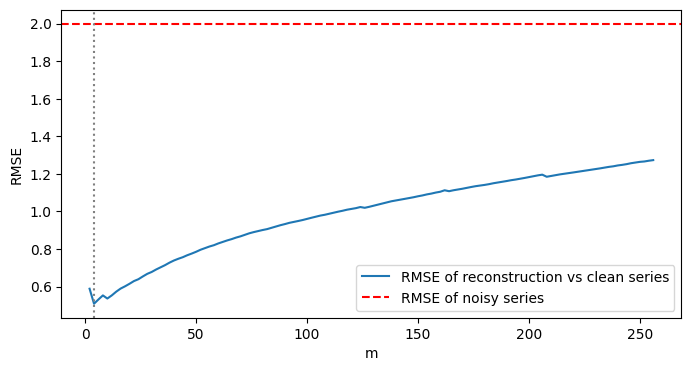

In [15]:
rng = np.random.default_rng(0)
sigma = 2.0
y_noisy = y + sigma * rng.standard_normal(N)

# Subtract the mean before transforming, and add it back after, exactly as
# you did in section 2. If you leave it in, coordinate k=0 is the largest
# of all and spends one of your m slots re-learning the average -- which
# makes the m=2 reconstruction look far worse than it is.

# ========= YOUR CODE STARTS HERE ========= #
c_noisy = dft(y_noisy - y_noisy.mean())
F_N = fourier_matrix(N)                      # built once; F_N @ coords is idft
ms = list(range(2, 257, 2))
rmse = []
for m in ms:
    rec = (F_N @ keep_largest(c_noisy, m)).real + y_noisy.mean()   # add the mean back
    rmse.append(np.sqrt(np.mean((rec - y) ** 2)))                  # against the CLEAN series
rmse = np.array(rmse)
rmse_noisy = np.sqrt(np.mean((y_noisy - y) ** 2))
best_m = ms[int(np.argmin(rmse))]
print(f"RMSE of the noisy series itself: {rmse_noisy:.3f}")
print(f"best m = {best_m}, RMSE there = {rmse.min():.3f}")
print(f"std of the non-seasonal part of the clean signal (4.2): {std_res:.3f}")

plt.figure(figsize=(8, 4))
plt.plot(ms, rmse, label="RMSE of reconstruction vs clean series")
plt.axhline(rmse_noisy, color="r", ls="--", label="RMSE of noisy series")
plt.axvline(best_m, color="gray", ls=":")
plt.xlabel("m"); plt.ylabel("RMSE"); plt.legend(); plt.show()
# ========== YOUR CODE ENDS HERE ========== #


---
### **YOUR ANSWER HERE**

1-2. The RMSE for each $m$ is plotted above; the minimising $m$ and its RMSE are printed (best $m$ = `best_m`). The curve starts well below the noisy series' RMSE ($\approx\sigma=2$) and goes back up for large $m$.
3. Because $F$ is unitary, white noise with variance $\sigma^2$ stays white: every coordinate contains noise of energy about $\sigma^2$, all coordinates alike. The signal's energy, on the other hand, sits in a few coordinates. Early on, each added coordinate is a signal coordinate that is far above the noise level, so we gain a lot of signal energy and the error falls. For large $m$ we add coordinates whose signal part is below the noise level: each one brings back about $\sigma^2$ of noise energy but recovers almost no signal, so the squared error grows roughly like $(\text{missing signal energy}+m\sigma^2)/N$. What is being added back is noise.
4. The non-seasonal part of the clean signal (std printed in 4.2) is spread flatly over all coordinates, with energy per coordinate of order its variance, much smaller than the noise energy $\sigma^2=4$ per coordinate. Those coordinates are buried in noise, so no choice of $m$ can recover them; the best we can do is to recover the seasonal part (and perhaps a few low-frequency trend coordinates) and the remaining error stays close to the std of the non-seasonal part (a bit lower only if some trend coordinates stand out of the noise).
5. The code is identical. What changed is the assumption about what is being discarded and the reference: in compression the small coordinates of a clean signal are dropped to save space and the error is measured against the signal itself; in denoising the small coordinates are assumed to be mostly noise, and the error is measured against the unknown clean signal, where dropping them is the whole point.

---


---
## 5. Summary

A few sentences each. These are where the defence starts.

1. The DFT is a change of basis. Name three concrete things in this notebook that would
   have failed, or needed extra work, if that basis had been merely a basis rather than an
   **orthonormal** one.
2. Core A found the annual cycle by being told to look for it; Core B found it by looking.
   Which would you use on a signal whose structure you did not already know, and what is
   the cost of that choice?
3. Compression and denoising were the same three lines of code. State the one sentence
   that explains why, and what distinguishes the two in practice.
4. You built $F$ explicitly and then were told never to do that again. When *is* the
   explicit matrix the right thing to have?

---
### **YOUR ANSWER HERE**

1. With a merely invertible (non-orthonormal) basis: (i) the coordinates would not be inner products; we would have to solve a linear system $Bc=x$ instead of computing $F^*x$, and `idft` would require the inverse instead of $F$ itself; (ii) Parseval would fail ($\operatorname{cond}\neq1$), so noise could be amplified in the coordinates, as in Core A; (iii) the truncation error would not equal the sum of the discarded $|c_k|^2$, and keeping the largest coordinates would not be the optimal choice (and zeroing coordinates would not be an orthogonal projection).
2. On a signal with unknown structure the Fourier approach (Core B), because it needs no prior guess. The cost: $N$ coordinates instead of a few parameters; it assumes uniformly spaced samples without gaps; it implicitly treats the record as periodic (end effects), and periods that do not divide $N$ leak over several indices. The model is also less interpretable than a small, targeted model.
3. Both operations are an orthogonal projection onto a coordinate subspace whose error is exactly the discarded energy, so keeping the largest coordinates is the best $m$-term approximation. They differ in what the discarded part is assumed to be: unimportant detail of a clean signal (compression, measured against the signal) or noise (denoising, measured against the unknown clean signal).
4. When $N$ is small, or the transform is applied many times to many vectors of the same size (one matrix-matrix product with BLAS beats the Python recursion, as the crossover in 3.2 shows); when the entries of the matrix themselves are needed (to inspect, modify or take its SVD/eigenvalues/condition number, as in 1.1); and when there is no fast structured algorithm for the matrix at all (for example the Core A design matrices).

---


---
---
# $\star$ Extension (bonus)

> **Optional. Up to 1 bonus point for the whole lab.** Attempt **at most one** of the three
> extensions &mdash; Extension 3 is below, Extensions 1 and 2 are at the end of Core A. The
> point is for a **finding you can defend**, not for code that ran. Say in your `README`
> which one you chose.

Everything above this line is Core B and is marked in full without this.


---
## $\star$ Extension 3 (bonus): DCT against DFT

The discrete cosine transform uses the orthonormal basis
$$ C_{kn} = \alpha_k \cos\!\Big(\frac{\pi (2n+1) k}{2N}\Big), \qquad
\alpha_0 = \sqrt{1/N},\ \alpha_k = \sqrt{2/N}\ (k \ge 1), $$
and it is the transform inside `jpeg` and most audio codecs. The usual claim is that its
coefficients decay faster than the DFT's. Test that claim on this series &mdash; and be
prepared for it to be only half true.

1. Build $C$ as a matrix, check that it is orthogonal, and check it against
   `scipy.fft.dct(x, norm='ortho')` if you have scipy.
2. For the mean-subtracted series, plot the sorted energies $|c_k|^2$ in both bases on one
   log-scale plot, and report how many coefficients each needs for 98% and for 99.5% of
   the energy. **Which basis wins?**
3. Now repeat on the **residual** from Core B 4.2 &mdash; the series with the annual pair
   removed. **Which basis wins now?**
4. The finding: explain both results. For the first, think about what $N = 12 \times 166$
   did for the DFT, and whether the DCT's cosines can represent a sinusoid of arbitrary
   phase. For the second, plot the residual and look at its two ends: what does the DFT
   assume happens after the last sample, and what does the DCT assume?
5. So: when is the DCT the better basis, and why is that the usual case for images?


In [ ]:
# ========= YOUR CODE STARTS HERE ========= #

# ========== YOUR CODE ENDS HERE ========== #


---
### **YOUR FINDING HERE**

(optional bonus: left empty)

---
